# NBA Player Injury Risk Profiling (Player-Week Dynamic Model)

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import joblib

# Step 1: Load and Clean Game Statistics

In [13]:
game_stats = pd.read_csv('Data/Cleaned/PlayerStatistics.csv', low_memory=False)
game_stats['gameDate'] = pd.to_datetime(game_stats['gameDate'], errors='coerce')

# Filter to seasons >2010
game_stats = game_stats[
    (game_stats['gameDate'].dt.year >= 2010)
]

game_stats.head()


,firstName,lastName,personId,gameId,gameDate,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
0,Russell,Westbrook,201566,42400173,2025-04-24 22:00:00,Denver,Nuggets,Los Angeles,Clippers,Playoffs,...,0.200,0.0,0.0,0.000,1.0,0.0,1.0,1.0,1.0,-16.0
1,Nicolas,Batum,201587,42400173,2025-04-24 22:00:00,Los Angeles,Clippers,Denver,Nuggets,Playoffs,...,0.667,0.0,0.0,0.000,5.0,0.0,5.0,1.0,0.0,23.0
2,DeAndre,Jordan,201599,42400173,2025-04-24 22:00:00,Denver,Nuggets,Los Angeles,Clippers,Playoffs,...,0.000,2.0,0.0,0.000,0.0,1.0,1.0,2.0,1.0,-1.0
3,James,Harden,201935,42400173,2025-04-24 22:00:00,Los Angeles,Clippers,Denver,Nuggets,Playoffs,...,0.375,6.0,5.0,0.833,4.0,2.0,6.0,0.0,1.0,25.0
4,Patty,Mills,201988,42400173,2025-04-24 22:00:00,Los Angeles,Clippers,Denver,Nuggets,Playoffs,...,1.000,0.0,0.0,0.000,0.0,0.0,0.0,1.0,1.0,6.0


# Step 2: Build Dynamic Player-Week Dataset

In [14]:
def infer_season(date):
    year = date.year
    if date.month >= 9:
        return f"{year}-{year+1}"
    else:
        return f"{year-1}-{year}"

# Create season column
game_stats['season'] = game_stats['gameDate'].apply(infer_season)
game_stats = game_stats.sort_values(['personId', 'gameDate']).reset_index(drop=True)

player_week_snapshots = []
seasons = game_stats['season'].unique()

for season in seasons:
    season_games = game_stats[game_stats['season'] == season]

    min_date = season_games['gameDate'].min()
    max_date = season_games['gameDate'].max()

    weekly_cutoffs = pd.date_range(start=min_date, end=max_date, freq='W-MON')

    for cutoff_date in weekly_cutoffs:
        games_until_now = season_games[season_games['gameDate'] <= cutoff_date]

        if games_until_now.empty:
            continue

        summary = games_until_now.groupby('personId').agg({
            'firstName': 'first',
            'lastName': 'first',
            'numMinutes': ['count', 'mean'],
            'points': 'mean',
            'assists': 'mean',
            'reboundsTotal': 'mean'
        }).reset_index()

        summary.columns = [
            'personId', 'firstName', 'lastName',
            'games_played', 'avg_minutes',
            'avg_points', 'avg_assists', 'avg_rebounds'
        ]

        rolling5 = games_until_now.groupby('personId').apply(
            lambda df: df.tail(5).agg({
                'numMinutes': 'mean',
                'points': 'mean'
            })
        ).reset_index()

        rolling5.columns = ['personId', 'rolling5_minutes', 'rolling5_points']

        games_until_now['days_since_last_game'] = games_until_now.groupby('personId')['gameDate'].diff().dt.days
        games_until_now['back_to_back_flag'] = (games_until_now['days_since_last_game'] <= 1).astype(int)
        b2b = games_until_now.groupby('personId')['back_to_back_flag'].sum().reset_index()
        b2b.columns = ['personId', 'back_to_back_games']

        merged = summary.merge(rolling5, on='personId', how='left').merge(b2b, on='personId', how='left')
        merged['season'] = season
        merged['cutoff_date'] = cutoff_date

        player_week_snapshots.append(merged)

player_week_data = pd.concat(player_week_snapshots, ignore_index=True)
player_week_data.head()


/var/folders/xx/yvjw0z0x5qs5dfnqdw9cnglh0000gn/T/ipykernel_87126/3043857035.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rolling5 = games_until_now.groupby('personId').apply(
/var/folders/xx/yvjw0z0x5qs5dfnqdw9cnglh0000gn/T/ipykernel_87126/3043857035.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_until_now['days_since_last_game'] = games_until_now.groupby('personId')['gameDate'].diff().dt.days
/var/folders/xx/yvjw0z0x5qs5dfnqdw9cnglh0000

,personId,firstName,lastName,games_played,avg_minutes,avg_points,avg_assists,avg_rebounds,rolling5_minutes,rolling5_points,back_to_back_games,season,cutoff_date
0,689,Theo,Ratliff,1,15.0,4.0,0.0,4.0,15.0,4.0,0,2010-2011,2010-10-04 15:00:00
1,965,Derek,Fisher,1,15.0,12.0,2.0,2.0,15.0,12.0,0,2010-2011,2010-10-04 15:00:00
2,977,Kobe,Bryant,1,6.0,0.0,2.0,1.0,6.0,0.0,0,2010-2011,2010-10-04 15:00:00
3,1885,Lamar,Odom,1,27.0,17.0,1.0,6.0,27.0,17.0,0,2010-2011,2010-10-04 15:00:00
4,1897,Metta,World Peace,1,17.0,3.0,2.0,1.0,17.0,3.0,0,2010-2011,2010-10-04 15:00:00


# Step 3: Standardize Features for Clustering and Modeling

In [15]:
# Load injuries
injuries = pd.read_csv('Data/Cleaned/injury_locations_scraped_categorized_named.csv')
injuries['Date'] = pd.to_datetime(injuries['Date'], errors='coerce')
injuries['full_name'] = injuries['Relinquished']

player_week_data['full_name'] = player_week_data['firstName'] + ' ' + player_week_data['lastName']

injury_counts_dynamic = []

injury_dates_lookup = injuries.groupby('full_name')['Date'].apply(list).to_dict()

# Loop over each player-week snapshot
for idx, row in player_week_data.iterrows():
    full_name = row['full_name']
    cutoff_date = row['cutoff_date']

    # Get all recorded injury dates for that player
    player_injuries = injury_dates_lookup.get(full_name, [])

    # Count how many injuries happened BEFORE cutoff date
    past_injuries = sum(date <= cutoff_date for date in player_injuries)

    injury_counts_dynamic.append(past_injuries)

player_week_data['injury_count'] = injury_counts_dynamic
player_week_data[['firstName', 'lastName', 'cutoff_date', 'injury_count']].head()

info = pd.read_csv("/Users/tymandachit/Documents/SW/MachineLearningProject/Data/CSV uncleaned/common_player_info.csv")
info['full_name'] = info['first_name'].str.strip() + ' ' + info['last_name'].str.strip()
info_subset = info[['full_name', 'height', 'weight', 'birthdate', 'position']]
info_subset['birthdate'] = pd.to_datetime(info_subset['birthdate'], errors='coerce')

# Merge and calculate age
player_week_data = player_week_data.merge(info_subset, on='full_name', how='left')
player_week_data['age'] = (
    (player_week_data['cutoff_date'] - player_week_data['birthdate'])
    .dt.days // 365
)

print(player_week_data[['firstName', 'lastName', 'cutoff_date', 'height', 'weight', 'position', 'age', 'injury_count']].head())



  firstName     lastName         cutoff_date height  weight       position  \
0      Theo      Ratliff 2010-10-04 15:00:00   6-10   235.0         Center   
1     Derek       Fisher 2010-10-04 15:00:00    6-1   210.0          Guard   
2      Kobe       Bryant 2010-10-04 15:00:00    6-6   212.0  Forward-Guard   
3     Lamar         Odom 2010-10-04 15:00:00   6-10   230.0        Forward   
4     Metta  World Peace 2010-10-04 15:00:00    6-7   260.0        Forward   

    age  injury_count  
0  37.0             0  
1  36.0             0  
2  32.0             0  
3  30.0             0  
4  30.0             0  


/var/folders/xx/yvjw0z0x5qs5dfnqdw9cnglh0000gn/T/ipykernel_87126/42416323.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_subset['birthdate'] = pd.to_datetime(info_subset['birthdate'], errors='coerce')


In [22]:
keep_cols = [
    'personId', 'firstName', 'lastName',
    'games_played', 'avg_minutes', 'avg_points', 'avg_assists', 'avg_rebounds',
    'rolling5_minutes', 'rolling5_points', 'back_to_back_games',
    'season', 'cutoff_date', 'full_name',
    'injury_count', 'height', 'weight', 'position', 'age', 'height_inches'
]

# Keep only these columns
player_week_data = player_week_data[keep_cols]

print(player_week_data.head())

player_week_data.to_csv('player_week_data_final.csv', index=False)

   personId firstName     lastName  games_played  avg_minutes  avg_points  \
0       689      Theo      Ratliff             1         15.0         4.0   
1       965     Derek       Fisher             1         15.0        12.0   
2       977      Kobe       Bryant             1          6.0         0.0   
3      1885     Lamar         Odom             1         27.0        17.0   
4      1897     Metta  World Peace             1         17.0         3.0   

   avg_assists  avg_rebounds  rolling5_minutes  rolling5_points  \
0          0.0           4.0              15.0              4.0   
1          2.0           2.0              15.0             12.0   
2          2.0           1.0               6.0              0.0   
3          1.0           6.0              27.0             17.0   
4          2.0           1.0              17.0              3.0   

   back_to_back_games     season         cutoff_date          full_name  \
0                   0  2010-2011 2010-10-04 15:00:00       

In [28]:
# Reload from saved CSV
data = pd.read_csv('player_week_data_final.csv', low_memory=False)
data['cutoff_date'] = pd.to_datetime(data['cutoff_date'], errors='coerce')

print(data.shape)

(328277, 20)


In [33]:
from sklearn.preprocessing import StandardScaler

# Selected feature columns for modeling
feature_cols = [
    'games_played',
    'avg_minutes',
    'avg_points',
    'avg_assists',
    'avg_rebounds',
    'rolling5_minutes',
    'rolling5_points',
    'back_to_back_games',
    'injury_count',
    'height_inches',
    'weight',
    'age'
]

# Identify rows with missing feature data
missing_mask = data[feature_cols].isnull().any(axis=1)
missing_rows = data.loc[missing_mask]

# Log dropped rows
print(f"Dropped {missing_rows.shape[0]} rows due to missing values.")
print(missing_rows[['full_name'] + [col for col in feature_cols if col in missing_rows.columns]].head())

# Drop rows with missing values in selected features
X = data[feature_cols].dropna()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preview scaled features
pd.DataFrame(X_scaled, columns=feature_cols).head()
print(X.shape)


Dropped 92059 rows due to missing values.
          full_name  games_played  avg_minutes  avg_points  avg_assists  \
16  Michael Beasley             1         18.0   21.000000     0.000000   
18     Kosta Koufos             1         11.0    0.000000     0.000000   
25     Drew Naymick             1         13.0    0.000000     0.000000   
26        Dee Brown             1          5.0    2.000000     0.000000   
38        Ray Allen             3         20.0    9.333333     1.666667   

    avg_rebounds  rolling5_minutes  rolling5_points  back_to_back_games  \
16           4.0              18.0        21.000000                   0   
18           5.0              11.0         0.000000                   0   
25           2.0              13.0         0.000000                   0   
26           1.0               5.0         2.000000                   0   
38           4.0              20.0         9.333333                   1   

    injury_count  height_inches  weight   age  
16      

# Step 4: Create Risk Groups using KMeans Clustering

In [49]:
from sklearn.cluster import KMeans

n_clusters = 3

# Train KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add clusters to scaled features
X_with_clusters = pd.DataFrame(X_scaled, columns=feature_cols)
X_with_clusters['risk_cluster'] = clusters

# Optional: reattach metadata like player name, date, etc.
X_with_clusters = pd.concat([X_with_clusters, data.loc[X.index, ['full_name', 'cutoff_date', 'season']].reset_index(drop=True)], axis=1)

# Preview
X_with_clusters.head()


,games_played,avg_minutes,avg_points,avg_assists,avg_rebounds,rolling5_minutes,rolling5_points,back_to_back_games,injury_count,height_inches,weight,age,risk_cluster,full_name,cutoff_date,season
0,-1.204449,-0.405563,-0.548765,-0.956552,0.388946,-0.354011,-0.511606,-1.238536,-0.3495,0.998910,0.607605,2.172234,1,Theo Ratliff,2010-10-04 15:00:00,2010-2011
1,-1.204449,-0.405563,0.792411,0.225922,-0.428832,-0.354011,0.664834,-1.238536,-0.3495,-1.633647,-0.360292,1.966835,1,Derek Fisher,2010-10-04 15:00:00,2010-2011
2,-1.204449,-1.396957,-1.219352,0.225922,-0.837721,-1.203280,-1.099826,-1.238536,-0.3495,-0.171116,-0.282860,1.145235,1,Kobe Bryant,2010-10-04 15:00:00,2010-2011
3,-1.204449,0.916296,1.630646,-0.365315,1.206724,0.778348,1.400110,-1.238536,-0.3495,0.998910,0.414025,0.734435,2,Lamar Odom,2010-10-04 15:00:00,2010-2011
4,-1.204449,-0.185253,-0.716412,0.225922,-0.837721,-0.165284,-0.658661,-1.238536,-0.3495,0.121391,1.575501,0.734435,1,Metta World Peace,2010-10-04 15:00:00,2010-2011


# Elbow Method to Validate Number of Clusters

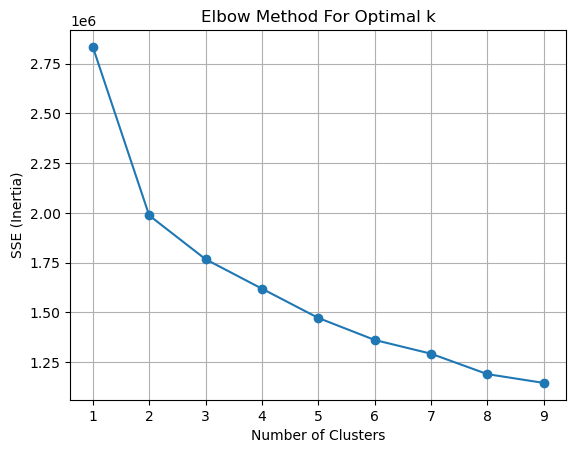

In [40]:
sse = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

# Plot
plt.plot(range(1, 10), sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

# Step 5: Train Supervised Models to Predict Risk Category

In [50]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, clusters, test_size=0.2, random_state=42, stratify=clusters
)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Evaluate
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix (KNN):\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report (KNN):\n", classification_report(y_test, y_pred_knn))

# Train Decision Tree
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

# Predict
y_pred_tree = tree.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nConfusion Matrix (Tree):\n", confusion_matrix(y_test, y_pred_tree))
print("\nClassification Report (Tree):\n", classification_report(y_test, y_pred_tree))

KNN Accuracy: 0.974261281855897

Confusion Matrix (KNN):
 [[14999   280   262]
 [  303 20235    23]
 [  309    39 10794]]

Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.96      0.97      0.96     15541
           1       0.98      0.98      0.98     20561
           2       0.97      0.97      0.97     11142

    accuracy                           0.97     47244
   macro avg       0.97      0.97      0.97     47244
weighted avg       0.97      0.97      0.97     47244

Decision Tree Accuracy: 0.9053636440606214

Confusion Matrix (Tree):
 [[13988   999   554]
 [ 1214 19220   127]
 [ 1458   119  9565]]

Classification Report (Tree):
               precision    recall  f1-score   support

           0       0.84      0.90      0.87     15541
           1       0.95      0.93      0.94     20561
           2       0.93      0.86      0.89     11142

    accuracy                           0.91     47244
   macro avg       0.91     

# Step 6: Save Trained Models

In [94]:
joblib.dump(knn, 'models/knn_model.pkl')
joblib.dump(tree, 'models/decision_tree_model.pkl')
joblib.dump(kmeans, 'models/kmeans_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

# Step 7: Visualize Risk Groups using PCA

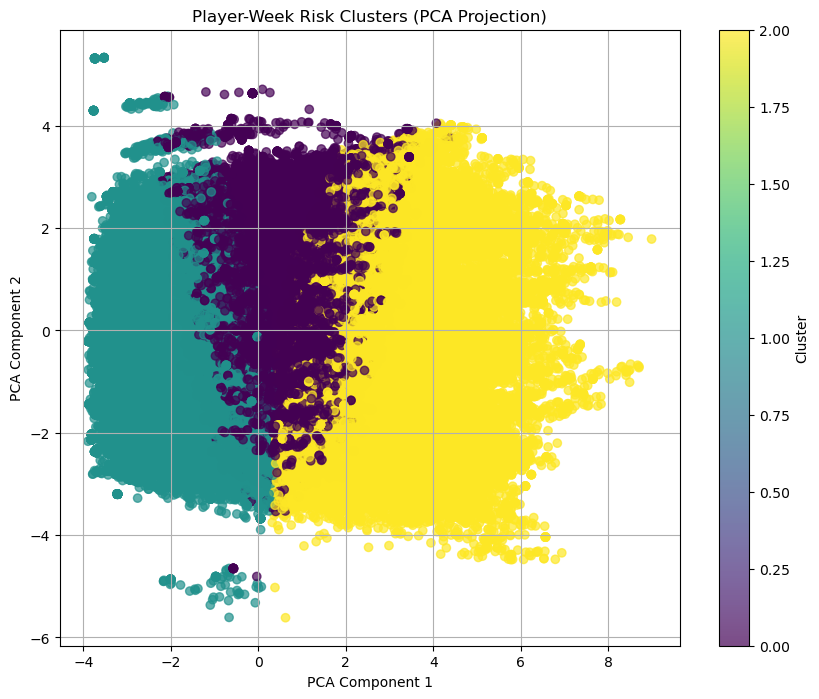

In [52]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Player-Week Risk Clusters (PCA Projection)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

# Step 8: Map Cluster IDs to Risk Levels

In [54]:
# Group player weeks by their assigned cluster
cluster_profile = player_week_data.loc[X.index].copy()
cluster_profile['risk_cluster'] = clusters

# Summarize key features
cluster_summary = cluster_profile.groupby('risk_cluster').agg({
    'injury_count': 'mean',
    'avg_minutes': 'mean',
    'back_to_back_games': 'mean',
    'games_played': 'mean'
}).reset_index()

# Display
cluster_summary


,risk_cluster,injury_count,avg_minutes,back_to_back_games,games_played
0,0,0.858737,20.522978,22.581049,50.013821
1,1,0.562336,11.046464,7.151452,12.870541
2,2,2.162260,30.204015,17.633475,44.202273


In [44]:
risk_mapping = {
    2: 'Low Risk',
    3: 'Medium Risk',
    0: 'High Risk',
    1: 'Very High Risk'
}

X_with_clusters['risk_level'] = X_with_clusters['risk_cluster'].map(risk_mapping)
X_with_clusters[['risk_cluster', 'risk_level']].head()


,risk_cluster,risk_level
0,3,Medium Risk
1,1,Very High Risk
2,3,Medium Risk
3,2,Low Risk
4,3,Medium Risk


# Step 9: Save Risk Mapping for Use in Web App

In [101]:
import json

with open('models/risk_mapping.json', 'w') as f:
    json.dump(risk_mapping, f)

# Step 10: Bonus — 3D PCA Visualization of Risk Clusters

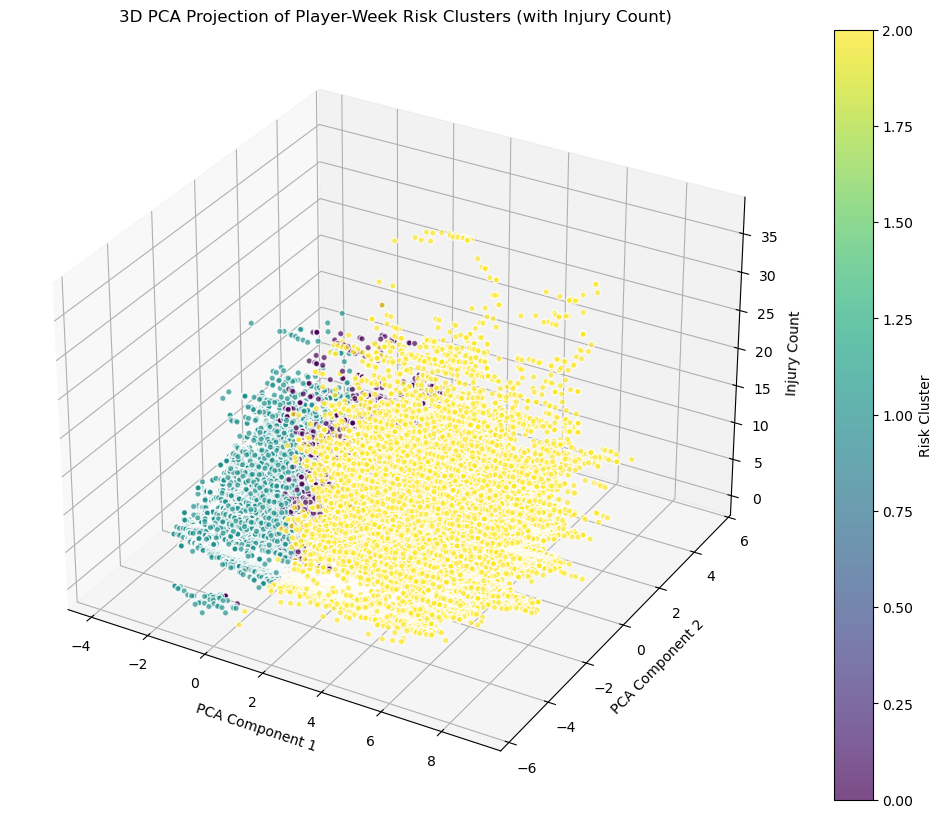

In [53]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Step 1: PCA with 2 components (X and Y)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 2: Real injury counts for Z-axis
injury_count = data.loc[X.index, 'injury_count'].values  # match rows

# Step 3: 3D Plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0],            # PCA Component 1 (X-axis)
    X_pca[:, 1],            # PCA Component 2 (Y-axis)
    injury_count,           # Real Injury Count (Z-axis)
    c=clusters,             # Color by risk cluster
    cmap='viridis',         
    alpha=0.7,
    edgecolors='w'
)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('Injury Count')
ax.set_title('3D PCA Projection of Player-Week Risk Clusters (with Injury Count)')

fig.colorbar(scatter, ax=ax, label='Risk Cluster')
plt.show()
